# HW2 TASK 2

# HW2 车辆检测与多目标跟踪越线计数
深度学习课程作业二：基于 YOLOv8 的道路车辆检测、跟踪与越线计数系统

## 一、项目简介
本项目使用 YOLOv8s 完成道路车辆多类别检测，结合 ByteTrack 实现多目标跟踪，并通过垂直中线实现车辆越线计数功能。
包含模型训练、推理、可视化、wandb 训练过程记录。

## 二、环境配置
```bash
pip install ultralytics wandb opencv-python
```

## 三、文件结构
├── YOLOtrain.py          # 模型训练脚本
├── YOLOcount.py        # 多目标跟踪 + 越线计数
├── data.yaml           # 数据集配置文件
├── best.pt               # 训练完成的最优模型
├── test2.mp4             # 测试视频

## 四、运行方法
1. 训练模型：python YOLOtrain.py
2. 越线计数：python YOLOcount.py


> W&B API key intentionally omitted. Set `WANDB_API_KEY` in the environment if online logging is needed.


## 模型训练

In [15]:
from YOLOtrain import main
main()


New https://pypi.org/project/ultralytics/8.4.47 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.46  Python-3.13.12 torch-2.11.0+cpu CPU (Intel Core Ultra 5 225H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\\2026\\HW2\trafic_data\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, na

## 多目标跟踪+越线计数

In [5]:
from YOLOcount import main
main()


正在启动推理...
输出文件将保存为: tracking_v8s_20260515_212142.mp4

0: 384x640 1 suv, 52.4ms
Speed: 1.5ms preprocess, 52.4ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 suv, 45.7ms
Speed: 0.8ms preprocess, 45.7ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 suv, 43.4ms
Speed: 0.9ms preprocess, 43.4ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 suv, 42.0ms
Speed: 0.9ms preprocess, 42.0ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 suv, 46.5ms
Speed: 0.9ms preprocess, 46.5ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 suv, 52.9ms
Speed: 1.0ms preprocess, 52.9ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 suv, 71.0ms
Speed: 1.0ms preprocess, 71.0ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 suv, 47.4ms
Speed: 1.0ms preprocess, 47.4ms inference, 0.6ms postprocess

# 基于YOLOv8的道路车辆检测与多目标跟踪越线计数系统

## 1. 实验概述
1. **实验任务**

    基于Ultralytics YOLOv8 框架完成道路车辆多类别检测，结合ByteTrack实现多目标跟踪，并设计垂直越线计数功能；结合校园实拍路口场景，分析遮挡场景下的ID跳变问题。

2. **模型结构**

    采用 **YOLOv8s（Small）** 目标检测模型，相比YOLOv8n拥有更强的特征提取能力与遮挡鲁棒性，更适合复杂交通场景。

3. **数据集介绍**

    数据集：道路车辆图像数据集（trafic_data），共2704张图像

    验证集：300张图像，共2568个车辆实例

    类别：car、bus、truck、suv、minivan等21类车辆

4. **任务流程** 

    模型微调训练 → 验证集指标评估 → 多目标跟踪（ByteTrack）→ 垂直线越线计数 → 遮挡与ID跳变现象分析。


## 2. 详细实验设置
| 实验配置项 | 具体参数值 |
|----------|------------|
| 深度学习框架 | PyTorch + Ultralytics 8.4.46 |
| 基础模型 | YOLOv8s.pt（官方预训练权重） |
| 训练/验证集划分 | 训练集2704张 / 验证集300张 |
| 输入图像尺寸 | 640×640 |
| Batch Size | 16 |
| 初始学习率 lr0 | 0.001 |
| 优化器 | AdamW（更适合小样本/类别不平衡数据集） |
| 训练最大Epoch | 100 |
| 早停策略 Patience | 10（连续10轮无提升自动停止） |
| 实际训练轮数 | 37轮（最佳轮数：第27轮） |
| 数据增强 | 开启（augment=True） |
| 损失函数 | YOLOv8 复合损失：Box损失 + Cls分类损失 + DFL分布焦点损失 |
| 评价指标 | mAP50、mAP50-95、精确率(Precision)、召回率(Recall) |
| 跟踪算法 | ByteTrack（多目标跟踪） |
| 计数方式 | 垂直中线越线计数 |
| 运行设备 | Intel Core Ultra 5 225H（CPU） |
| 可视化工具 | Weights & Biases（wandb） |



## 3. Wandb 可视化结果
1. **训练收敛性**

   训练共执行37轮后触发早停，**最佳模型出现在第27轮**，训练集与验证集损失持续下降并逐步收敛，无明显过拟合。

2. **wandb可视化截图**
   - 训练集/验证集 **Box/Cls/DFL 损失曲线**
   - 验证集 **mAP50 / mAP50-95 指标曲线**
   - 精确率、召回率变化曲线

3. **训练行为**

   开启数据增强提升模型对遮挡、尺度变化的鲁棒性；使用AdamW优化器与较小学习率（0.001）保证微调稳定性，避免破坏预训练权重。



## 4. 实验结果
模型在验证集上的综合指标：
- 精确率（Precision）：**0.667**
- 召回率（Recall）：**0.412**
- mAP50：**0.520**
- mAP50-95：**0.304**

各类别关键表现：
- car（轿车）：mAP50 = **0.790**（表现最优）
- bus（公交）：mAP50 = 0.663
- three wheelers -CNG-：mAP50 = 0.724
- rickshaw：mAP50 = 0.733
- suv/van等少样本类别精度较低，是跟踪中ID跳变的次要原因。

## 5. 超参数选择与调优思路

研究在最终确定过程中对使用模型及相关超参数进行了比较和选择：

1. **从 YOLOv8n 升级为 YOLOv8s**
   提升模型容量，增强特征提取与遮挡情况下的检测稳定性。
2. **优化器更换为 AdamW**
   对样本不平衡、小类别更友好，收敛更平稳。
3. **学习率设为 0.001**
   微调阶段使用小学习率，防止权重震荡。
4. **开启数据增强 augment=True**
   提升模型对遮挡、运动模糊、姿态变化的泛化能力。
5. **patience=10 早停**
   在CPU训练下节省时间，同时避免过拟合。

## 6. 实验总结与改进方向
总结：完成车辆检测、多目标跟踪、越线计数全流程；遮挡会导致ID跳变，模型对小样本类别检测精度较低。
改进：增加遮挡数据增强、提高跟踪器 `iou` 阈值、补充低精度类别数据集等



### 任务 2(3)：遮挡与 ID 跳变分析

#### 1. 可视化展示

在本实验选取的关键帧，主要观察红色的 **ID: 26 SUV** 与背景中两辆白色小车的交互过程。

* **Frame 379**：初始状态。左后方两辆白车分别为 **ID: 20 (car)** 与 **ID: 22 (car)**，此时运动平稳，跟踪正常。

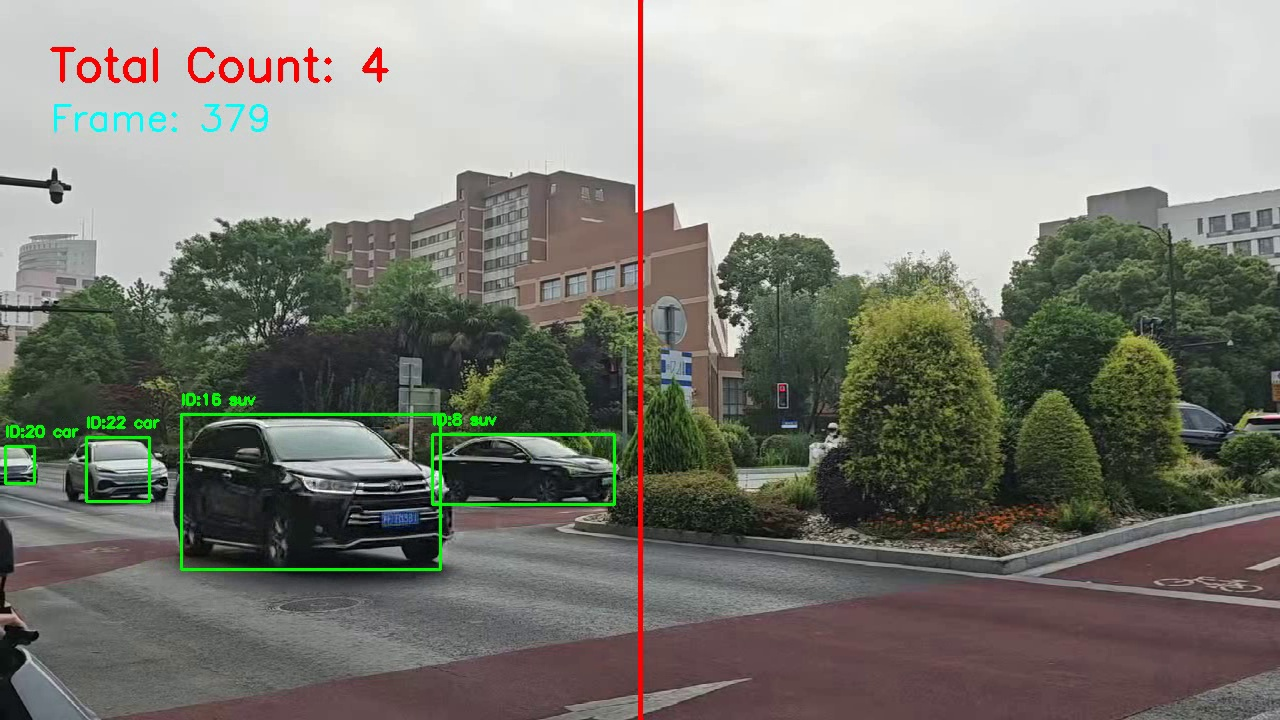

* **Frame 425**：发生密集交汇与遮挡。红色 **ID: 26 (SUV)** 快速驶入并遮挡了后方白车。此时原 **ID: 20** 的白车发生了 **ID 跳变（ID Switch）**，变为了 **ID: 33 (car)**。

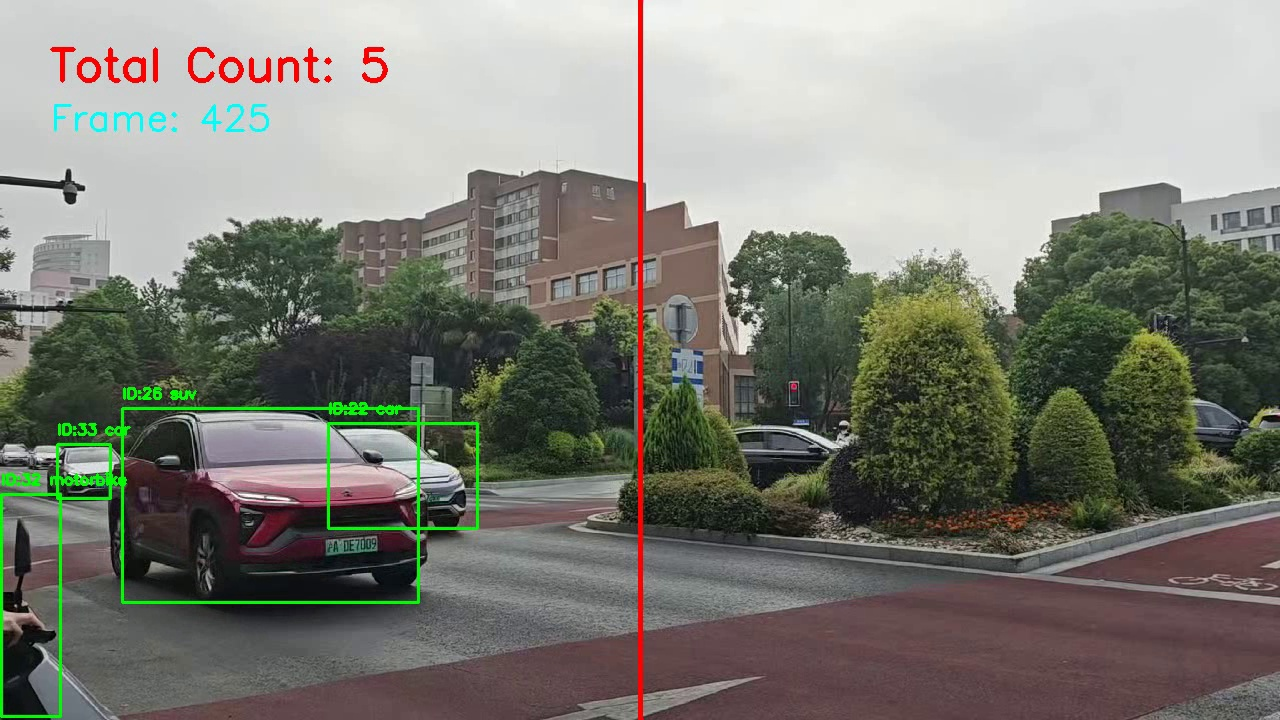


* **Frame 441**：遮挡结束。红色 **ID: 26** 完全超过前方白车。值得注意的是，前方白车虽然成功维持了 **ID: 22**，但其类别属性从 **car** 误跳变为 **suv**。

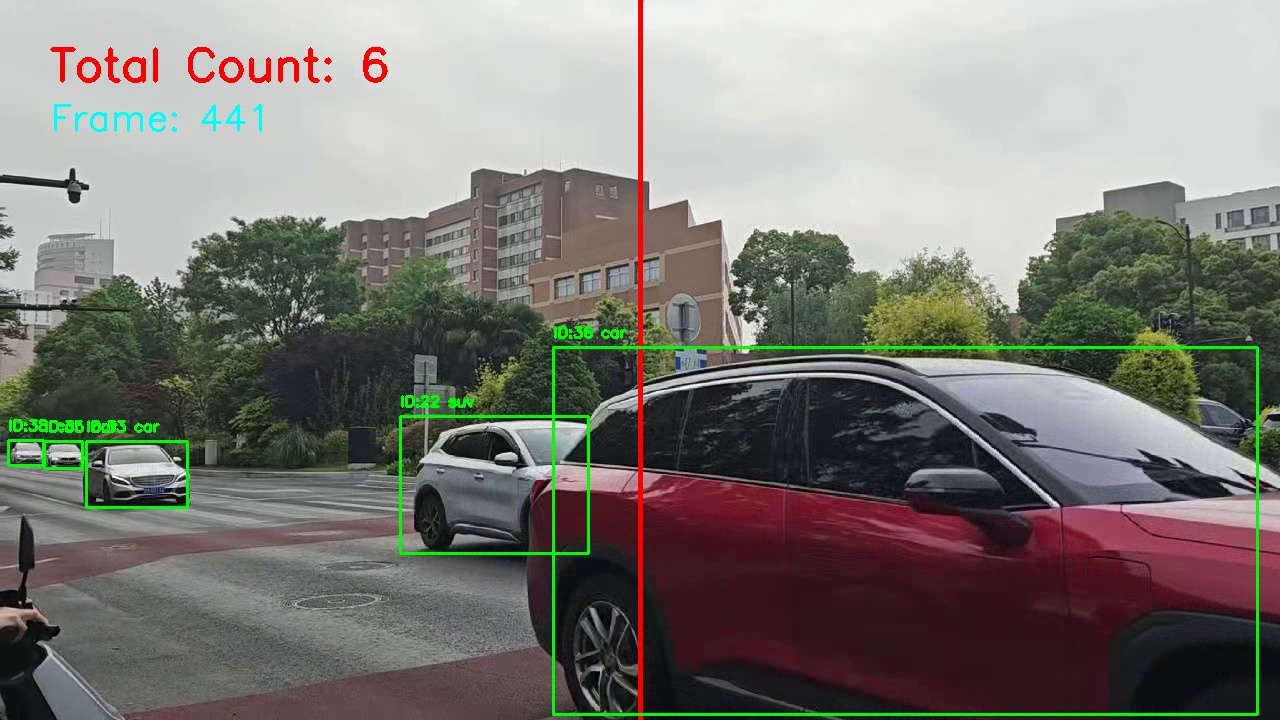



#### 2. 原理分析与原因总结

本次实验采用多目标任务检测 + 内置tracking跟踪，流程如下：

* **检测阶段**：YOLOv8 对每帧输出目标的边界框、置信度和类别；
* **跟踪阶段**：ByteTrack 通过两步维持轨迹：
   - 卡尔曼滤波预测目标的运动轨迹；
   - 匈牙利算法结合 **IOU（交并比）** 和特征匹配，将当前检测框与历史轨迹关联：
     - 匹配成功：保留原有 ID，更新轨迹；
     - 匹配失败：标记为“丢失目标”，若长时间无法匹配，则分配新 ID。

当目标被遮挡时，检测框会出现漂移、置信度下降或漏检，直接导致跟踪匹配失败，触发 ID 跳变

##### 2.1 遮挡场景下ID 跳变（ID: 20 → ID: 33）的原因分析

在 Frame 425 中，后方白车由于被红色 SUV 大面积遮挡，导致跟踪算法在面对此场景时发生了**目标丢失后重新分配 ID** 的现象：

* **检测器失效与置信度下降**： 受限于检测器本身，指标显示，模型整体召回率不高，当红色 SUV 遮挡白车时，虽然 ByteTrack 尝试利用低分框进行二次关联 ，但由于遮挡比例过大（白色车辆被近处的红色SUV完全遮挡）且遮挡时间较长，导致检测框特征极不完整，而目标特征受损导致检测器生成的边界框置信度剧烈下降，跌破 ByteTrack 的匹配阈值。


* **卡尔曼滤波预测偏差**：在目标完全丢失的几帧内，跟踪器依赖卡尔曼滤波预测位置。而白色车辆正处准备跨越路口并且等待前方车辆通行的过程中，发生了减速和停滞，预测框与重新出现的检测框 IoU 匹配失败，系统便认为原目标已消失，并在目标重现时分配了新 ID (ID: 33)。

* **小目标关联失败**：后方白车成像尺寸较小，卡尔曼滤波的预测精度在小尺度下更容易产生 IoU 偏移。

##### 2.2. ID 成功维持（ID: 22）的原理

前方白车在被红色 SUV 掠过时，成功维持了 **ID: 22**。

* **ByteTrack 的双重匹配机制**：前方白车与红色SUV此时均处于画面较为中间的位置，并且红车相较于跨越第一辆白车的时候速度提升，二者交汇时间较短，在红车超车完成之后，基于卡尔曼滤波的轨迹预测机制，信的检测框与预测轨迹的IOU仍然在模型设定的相对较高的匹配阈值内，因而能够被成功关联，维持了原始ID。

* **轨迹丢失容许时间宽度**: ByteTrack为短暂丢失的轨迹保留一定时间，在较短的遮蔽后，白色轿车轨迹重新出现，未被判定为“永久丢失”，故没有一开始就分配新的ID



##### 2.3 类别跳变（car → suv）的现象解释

在 Frame 441 中，**ID: 22** 发生了类别识别错误。

* **YOLO检测精度**：跟踪算法通常只负责维持 ID 的连续性，而类别判定每帧都由 YOLO 检测头输出。由于 Frame 441 中红色 SUV 占据了画面视觉重心，且白车在红色车身映衬下特征受损，导致分类器产生了瞬间误判。
* **类别精度不均导致的偏向性**：实验数据显示 car 的 mAP50 为 0.764，而 SUV 仅为 0.223。分类器在处理 SUV 这种性能较差的类别时边界模糊。
* **特征污染与语义干扰**：在遮挡接触瞬间，红色 SUV（ID:26）占据了显著的视觉空间。由于 YOLO 的特征提取受到邻近像素影响，白车的特征中混入了 SUV 的边缘特征，导致模型在分类头输出时产生了误判。


#### 3. 总结

本次跟踪实验证明了 ByteTrack + YOLOv8 在处理中等程度遮挡（如 ID:22）时具有较好的鲁棒性，主要归功于其双重匹配机制。然而，在面对小尺度目标与长时间遮挡的耦合场景时，单纯依赖位置信息的关联逻辑容易失效。